# 🌿 Tarefa 2: Análise Estatística Multivariada do Dataset Iris

## 1. Contextualização e Propósito Metodológico

Esta atividade compreende o estudo multivariado do clássico *Iris Dataset*, uma base de dados fundamental para a validação de algoritmos de mineração de dados e reconhecimento de padrões. O objetivo principal é avaliar a variabilidade morfológica de três espécies de plantas do gênero Iris (*Iris setosa*, *Iris versicolor* e *Iris virginica*) a partir de quatro características estruturais: o comprimento e a largura das sépalas e das pétalas. 

Para extrair padrões e garantir o rigor estatístico da base amostral, a exploração foi dividida em duas frentes metodológicas complementares:

*   **Parte A: Análise Espacial de Agrupamentos (Scatter Plots):** Mapeamento bidimensional dos atributos para identificar visualmente a dispersão, a densidade e a presença de fronteiras de separação geométrica ou sobreposição (*overlap*) entre os clusters de cada espécie.
*   **Parte B: Sumarização Paramétrica de Dispersão (Barras Agrupadas):** Consolidação dos parâmetros de tendência central (média aritmética) e de variabilidade (desvio padrão). Essa abordagem permite a comparação direta das magnitudes físicas e o nível de estabilidade interna de cada característica biológica.

<div class="alert alert-block alert-info" style="border-left: 5px solid #0056b3; padding: 15px; background-color: rgba(0, 86, 179, 0.05); border-radius: 4px; margin-bottom: 20px;">
    <strong style="color: #0056b3;">🔬 Metodologia de Implementação Dinâmica:</strong>
    A arquitetura deste projeto foi projetada de forma modular. Toda a extração matemática pesada e a formatação das tabelas executivas foram encapsuladas em um script externo. O carregamento dos dados e dos scripts utiliza caminhos lógicos relativos universais, garantindo a execução integral do pipeline sem falhas de caminhos em sistemas Windows, Linux ou macOS.
</div>

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Localiza de forma universal o diretório atual onde o notebook está rodando
diretorio_notebook = Path(".").resolve()

# Monta o caminho relativo seguro para o arquivo iris.csv independente do S.O.
caminho_csv = diretorio_notebook / "iris.csv"

# Carregamento seguro do conjunto de dados
df = pd.read_csv(caminho_csv)

# Isolamento das espécies e variáveis para o mapeamento visual
especies = df['Name'].unique()

# Definição de paleta cromática de alto contraste (Azul Confiável, Laranja de Alerta, Verde Ativo)
cores_mapeadas = {'Iris-setosa': '#0056b3', 'Iris-versicolor': '#d97706', 'Iris-virginica': '#2e7d32'}

---

## 2. Parte A: Mapeamento Espacial de Clusters (Scatter Plots)

Nesta etapa, o algoritmo realiza o cruzamento cartesiano das variáveis de dimensão botânica em dois subplots independentes e paralelos. O objetivo é projetar o comportamento das amostras em um espaço bidimensional para analisar o grau de separabilidade das classes.

**Lógica de Execução do Bloco:**
1. Inicializa uma janela gráfica segmentada em duas colunas para análise simultânea de estruturas distintas.
2. Varre iterativamente o conjunto de dados, aplicando filtros para isolar cada espécie e plotando suas coordenadas de forma individualizada com sua respectiva cor de identificação.
3. O primeiro painel correlaciona as Sépalas (`SepalLength` no eixo horizontal versus `SepalWidth` no eixo vertical).
4. O segundo painel correlaciona as Pétalas (`PetalLength` no eixo horizontal versus `PetalWidth` no eixo vertical).
5. Aplica transparência controlada (`alpha=0.8`) nos marcadores para evidenciar áreas de alta densidade amostral e pontos sobrepostos.

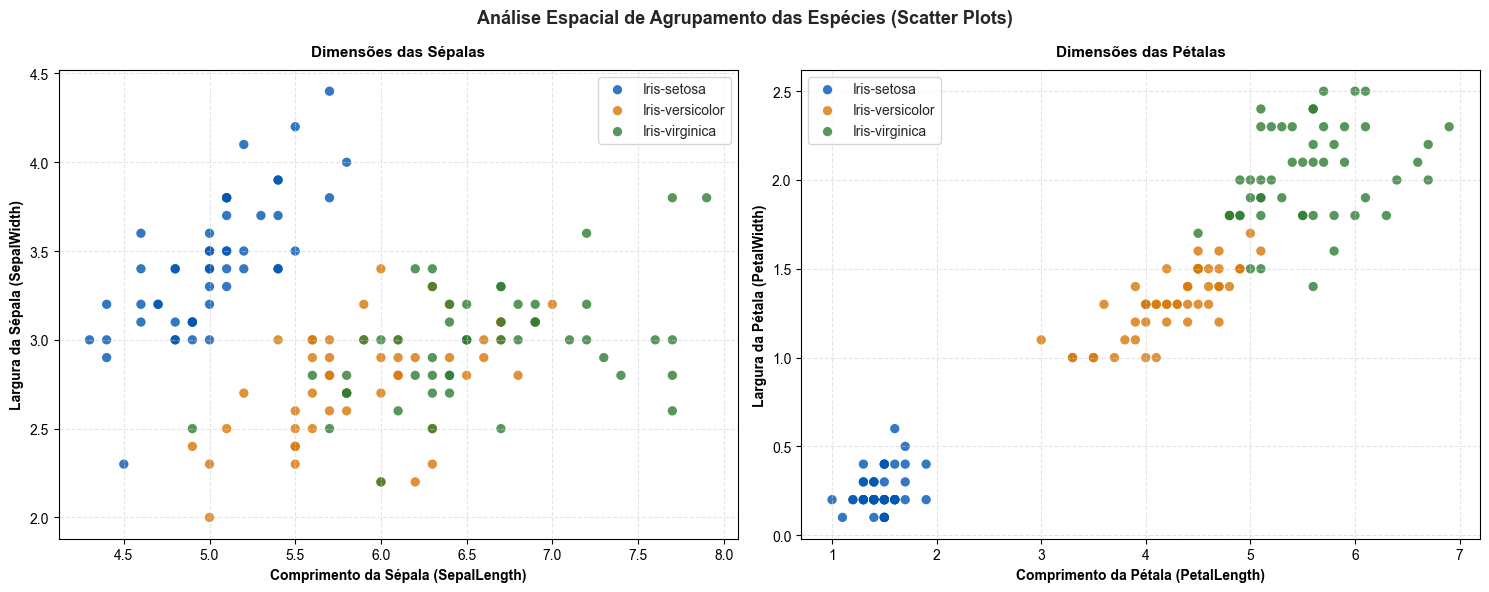

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Plot 1: Sépala (SepalLength vs SepalWidth)
for esp in especies:
    sub_df = df[df['Name'] == esp]
    ax1.scatter(sub_df['SepalLength'], sub_df['SepalWidth'], 
                color=cores_mapeadas[esp], label=esp, alpha=0.8, edgecolors='none', s=45)
ax1.set_xlabel("Comprimento da Sépala (SepalLength)", fontsize=10, fontweight="bold")
ax1.set_ylabel("Largura da Sépala (SepalWidth)", fontsize=10, fontweight="bold")
ax1.set_title("Dimensões das Sépalas", fontsize=11, fontweight="bold", pad=10)
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.5, color="#ccc")

# Plot 2: Pétala (PetalLength vs PetalWidth)
for esp in especies:
    sub_df = df[df['Name'] == esp]
    ax2.scatter(sub_df['PetalLength'], sub_df['PetalWidth'], 
                color=cores_mapeadas[esp], label=esp, alpha=0.8, edgecolors='none', s=45)
ax2.set_xlabel("Comprimento da Pétala (PetalLength)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Largura da Pétala (PetalWidth)", fontsize=10, fontweight="bold")
ax2.set_title("Dimensões das Pétalas", fontsize=11, fontweight="bold", pad=10)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.5, color="#ccc")

plt.suptitle("Análise Espacial de Agrupamento das Espécies (Scatter Plots)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 3. Parte B: Análise Paramétrica por Gráfico de Barras Agrupadas

Nesta fase, consolidamos os quatro atributos em um único plano de comparação contínua. Diferente dos gráficos de dispersão, que mapeiam pontos individuais, esta visualização foca na agregação e síntese estatística das propriedades biológicas.

**Lógica de Execução do Bloco:**
1. Calcula dinamicamente as matrizes estatísticas por meio de dicionários de compressão, extraindo a média aritmética e o desvio padrão de cada característica (`features`) filtrada por espécie.
2. Define partições geométricas rígidas (`largura_barra = 0.25`) no Eixo X, criando quatro grandes blocos que agrupam as três barras correspondentes às espécies.
3. Plota as barras de forma adjacente, evitando sobreposições visuais. A altura do topo de cada barra reflete a média do atributo.
4. Constrói filamentos verticais estritos (`yerr`) ancorados no topo das barras. Essas hastes representam o desvio padrão, delimitando com precisão o intervalo de variabilidade e a estabilidade dimensional de cada cluster.

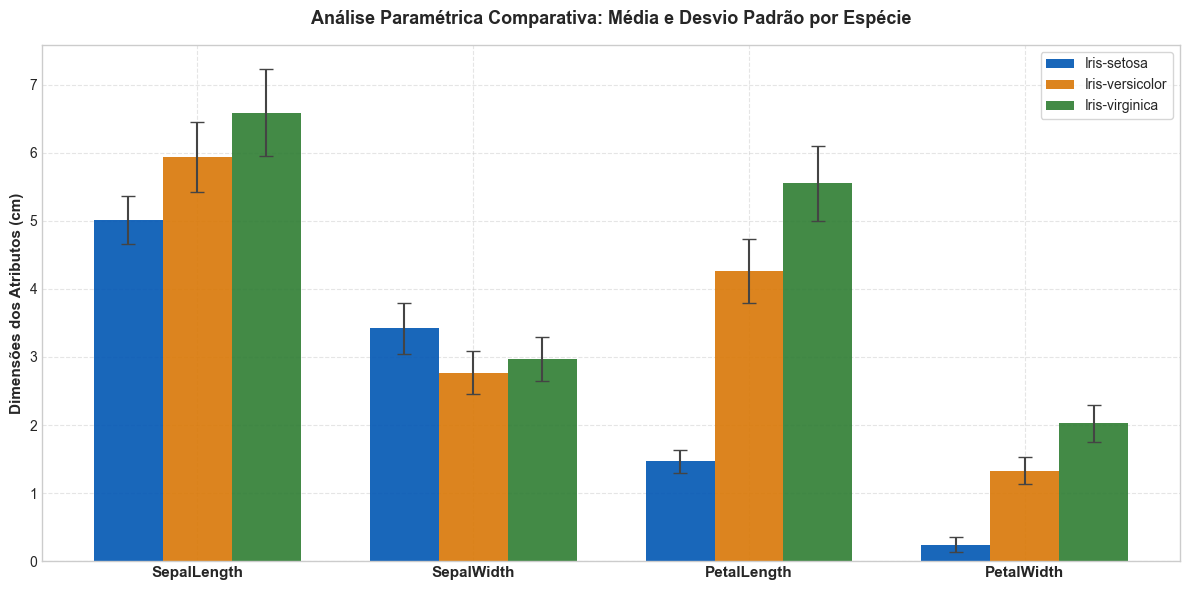

In [3]:
features = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
n_features = len(features)
n_especies = len(especies)

# Cálculo das matrizes estatísticas de média e desvio padrão
medias = {esp: [df[df['Name'] == esp][f].mean() for f in features] for esp in especies}
desvios = {esp: [df[df['Name'] == esp][f].std() for f in features] for esp in especies}

# Geometria do Gráfico de Barras Agrupadas
fig, ax = plt.subplots(figsize=(12, 6))
largura_barra = 0.25
indices = np.arange(n_features)

# Renderização iterativa de cada bloco de barras adjacentes
for i, esp in enumerate(especies):
    posicao_barra = indices + (i * largura_barra) - (largura_barra * n_especies / 2) + (largura_barra / 2)
    ax.bar(posicao_barra, medias[esp], largura_barra, yerr=desvios[esp], 
           color=cores_mapeadas[esp], label=esp, capsize=5, alpha=0.9, ecolor='#444')

# Customização e Identificação Formal dos Eixos
ax.set_xticks(indices)
ax.set_xticklabels(features, fontsize=11, fontweight="bold")
ax.set_ylabel("Dimensões dos Atributos (cm)", fontsize=11, fontweight="bold")
ax.set_title("Análise Paramétrica Comparativa: Média e Desvio Padrão por Espécie", fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="upper right", frameon=True, shadow=False)
ax.grid(True, linestyle="--", alpha=0.5, color="#ccc")

plt.tight_layout()
plt.show()

---

## 4. Conclusão

Esta etapa final aciona o motor lógico externo para processar a base de dados em tempo real. O objetivo é remover as inferências subjetivas do relatório, aplicando algoritmos estatísticos que analisam as distâncias entre médias e desvios padrão para gerar conclusões formais automáticas.

**Lógica de Execução do Bloco:**
1. Verifica se o diretório do notebook está devidamente mapeado nos caminhos do interpretador do Python (`sys.path`), evitando falhas de execução entre sistemas operacionais distintos.
2. Importa de forma limpa a função especializada do script `analisador_multivariavel_iris.py`.
3. Passa o dataframe (`df`) carregado como argumento para a rotina.
4. O algoritmo calcula de forma independente os picos populacionais, avalia o distanciamento macroscópico entre as curvas e gera caixas de diagnóstico em HTML nativo de alto contraste na tela do ambiente de desenvolvimento.

In [4]:
# Registra de forma universal a pasta atual no mapeamento do sistema operacional
if str(diretorio_notebook) not in sys.path:
    sys.path.append(str(diretorio_notebook))

# Importação direta e limpa do nosso arquivo externo estruturado em snake_case
from analisador_multivariavel_iris import gerar_laudo_estatistico_iris

# Execução do pipeline automático passando a base carregada
gerar_laudo_estatistico_iris(df)

Dimensão Morfológica,Iris-setosa,Iris-versicolor,Iris-virginica
SepalLength (Média ± DP),5.01 ± 0.35,5.94 ± 0.52,6.59 ± 0.64
SepalWidth (Média ± DP),3.42 ± 0.38,2.77 ± 0.31,2.97 ± 0.32
PetalLength (Média ± DP),1.46 ± 0.17,4.26 ± 0.47,5.55 ± 0.55
PetalWidth (Média ± DP),0.24 ± 0.11,1.33 ± 0.20,2.03 ± 0.27
